### Setup and Library Installation
First, we'll install the necessary libraries: `datasets` for loading the data, `transformers` for the BERT model, `torch` as a backend for `transformers`, and `matplotlib`/`pandas` for data manipulation and visualization.

In [ ]:
%%capture
!pip install datasets transformers torch pandas matplotlib


### Import Libraries and Initialize Model
Now, we import the required libraries and initialize a pre-trained sentiment analysis model from the Hugging Face Transformers library. We'll use `distilbert-base-uncased-finetuned-sst-2-english` as it's efficient and good for general sentiment tasks. We'll also set up the device for computation (GPU if available, otherwise CPU).

In [ ]:
import torch
from transformers import pipeline
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Initialize the sentiment analysis pipeline
device = 0 if torch.cuda.is_available() else -1  # Use GPU if available
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=device)

print(f"Using device: {"GPU" if device == 0 else "CPU"}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Using device: GPU


### Load Data, Sample, and Analyze Sentiment
We will load the `fddemarco/pushshift-reddit-comments` dataset in streaming mode. This dataset contains multiple monthly files. For each month, we'll sample approximately 1000 comments to keep the analysis manageable and then perform sentiment analysis on them. We'll store the results, including the month and the sentiment score.

In [ ]:
import pandas as pd
from tqdm.auto import tqdm
from datasets import load_dataset

dataset_name = "fddemarco/pushshift-reddit-comments"
sample_size_per_month = 10000

# Generate paths for 50 files starting from 2012-01
file_patterns = []
year, month = 2012, 1
for _ in range(50):
    file_patterns.append(f"data/RC_{year}-{month:02d}.parquet")
    month += 1
    if month > 12:
        month = 1
        year += 1

print(f"Attempting to process {len(file_patterns)} monthly files with random sampling...")

results = []

for file_name in tqdm(file_patterns, desc="Processing Files", unit="file"):
    try:
        # Load specific file in streaming mode
        month_ds = load_dataset(dataset_name, data_files=file_name, split="train", streaming=True)

        # Shuffle the stream with a buffer to ensure randomness without significant overhead
        # seed=42 ensures reproducibility
        shuffled_ds = month_ds.shuffle(seed=42, buffer_size=1000)

        texts = []
        for example in shuffled_ds:
            body = example.get('body', '')
            if body and len(body) > 10:
                texts.append(body)
            if len(texts) >= sample_size_per_month:
                break

        if texts:
            month_label = file_name.split('/')[-1].replace('RC_', '').replace('.parquet', '')

            sentiments = sentiment_pipeline(texts, truncation=True, batch_size=16)
            is_pos = [1 if s['label'] == 'POSITIVE' else -1 if s['label'] == 'NEGATIVE' else 0 for s in sentiments]
            avg_sentiment = sum(is_pos) / len(is_pos)

            results.append({
                'month': month_label,
                'avg_sentiment': avg_sentiment
            })

    except Exception as e:
        continue

# Final display and sorting
sentiment_df = pd.DataFrame(results)
if not sentiment_df.empty:
    sentiment_df['month'] = pd.to_datetime(sentiment_df['month'])
    sentiment_df = sentiment_df.sort_values('month')
    display(sentiment_df)
else:
    print("No data collected. Please verify file availability.")

Attempting to process 50 monthly files with random sampling...


Processing Files:   0%|          | 0/50 [00:00<?, ?file/s]

,month,avg_sentiment
0,2012-01-01,-0.2984
1,2012-02-01,-0.3026
2,2012-03-01,-0.3070
3,2012-04-01,-0.2972
4,2012-05-01,-0.2962
5,2012-06-01,-0.2778
6,2012-07-01,-0.3080
7,2012-08-01,-0.2826
8,2012-09-01,-0.3066
9,2012-10-01,-0.2960


### Download Analysis Results
Use the following cell to download the `sentiment_df` as a CSV file.

In [ ]:
# from google.colab import files

# if 'sentiment_df' in globals():
#     filename = 'reddit_sentiment_analysis.csv'
#     sentiment_df.to_csv(filename, index=False)
#     files.download(filename)
#     print(f'Successfully prepared {filename} for download.')
# else:
#     print('sentiment_df not found. Please run the data processing cell first.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully prepared reddit_sentiment_analysis.csv for download.


### Visualize Sentiment Over Time
Finally, we'll plot the average sentiment score over time to observe any trends or patterns. A higher score indicates more positive sentiment.

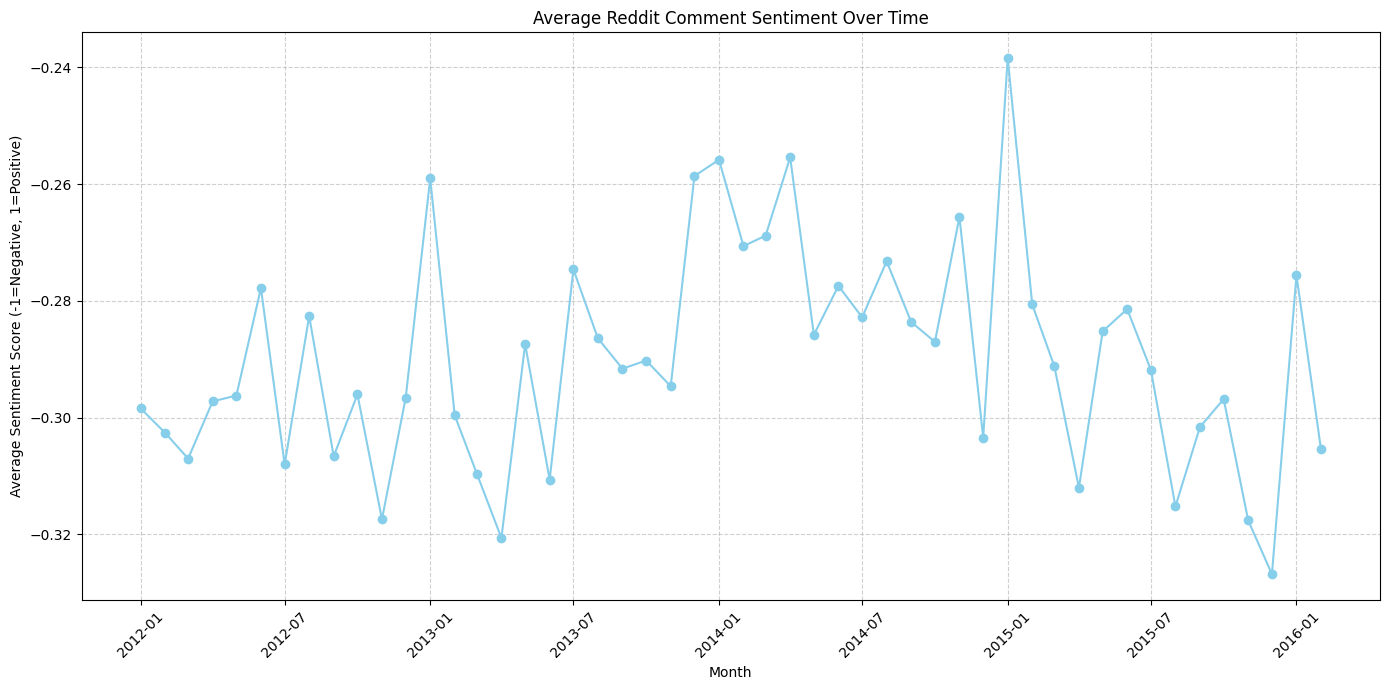

In [ ]:
if not sentiment_df.empty:
    plt.figure(figsize=(14, 7))
    plt.plot(sentiment_df['month'], sentiment_df['avg_sentiment'], marker='o', linestyle='-', color='skyblue')
    plt.title('Average Reddit Comment Sentiment Over Time')
    plt.xlabel('Month')
    plt.ylabel('Average Sentiment Score (-1=Negative, 1=Positive)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No sentiment data to plot. Please check if the dataset was processed correctly.")


### Annual Sentiment Trends
We aggregate the monthly data by year to smooth out short-term fluctuations and observe the broader annual trend.

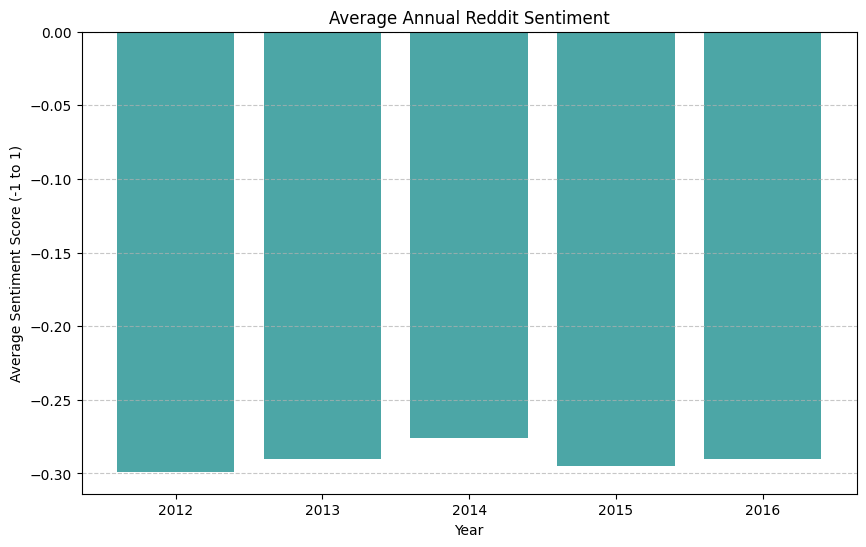

In [ ]:
if not sentiment_df.empty:
    annual_sentiment = sentiment_df.groupby(sentiment_df['month'].dt.year)['avg_sentiment'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    plt.bar(annual_sentiment['month'].astype(str), annual_sentiment['avg_sentiment'], color='teal', alpha=0.7)
    plt.title('Average Annual Reddit Sentiment')
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment Score (-1 to 1)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No data available for annual plotting.")

### Overall Sentiment Distribution
Finally, we look at the total percentage of positive vs negative classifications across the entire sampled period.

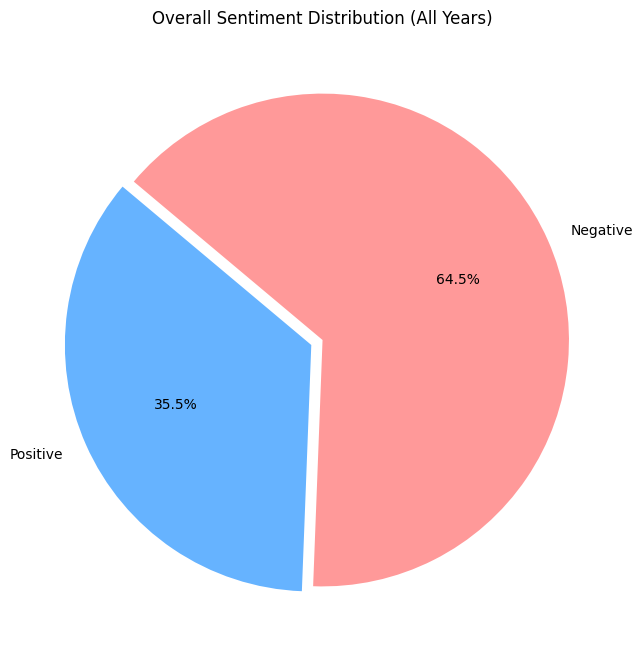

In [ ]:
# To get precise percentages, we'll calculate based on the monthly averages
# which represent the ratio of positive to total in our -1/1 scheme
if not sentiment_df.empty:
    # Since avg = (pos - neg) / total and pos + neg = total
    # pos_pct = (avg + 1) / 2
    avg_overall = sentiment_df['avg_sentiment'].mean()
    pos_pct = (avg_overall + 1) / 2 * 100
    neg_pct = 100 - pos_pct

    labels = ['Positive', 'Negative']
    sizes = [pos_pct, neg_pct]
    colors = ['#66b3ff', '#ff9999']

    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
    plt.title('Overall Sentiment Distribution (All Years)')
    plt.show()
else:
    print("No data available for distribution plotting.")

### Statistical Analysis of Sentiment Scores
We will perform descriptive statistical analysis and check the distribution of the monthly sentiment averages.

In [ ]:
from scipy import stats

if not sentiment_df.empty:
    # Descriptive Statistics
    stats_summary = sentiment_df['avg_sentiment'].describe()
    print("--- Descriptive Statistics ---")
    print(stats_summary)

    # Median and Variance
    print(f"\nMedian: {sentiment_df['avg_sentiment'].median():.4f}")
    print(f"Variance: {sentiment_df['avg_sentiment'].var():.4f}")

    # Normality Test (Shapiro-Wilk)
    # Null hypothesis: The data is normally distributed
    shapiro_test = stats.shapiro(sentiment_df['avg_sentiment'])
    print("\n--- Shapiro-Wilk Test for Normality ---")
    print(f"Statistic: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")

    if shapiro_test.pvalue > 0.05:
        print("The distribution appears to be normal (fail to reject H0).")
    else:
        print("The distribution does not appear to be normal (reject H0).")
else:
    print("No data available for statistical analysis.")

--- Descriptive Statistics ---
count    50.000000
mean     -0.289964
std       0.018924
min      -0.326800
25%      -0.303200
50%      -0.291400
75%      -0.278500
max      -0.238400
Name: avg_sentiment, dtype: float64

Median: -0.2914
Variance: 0.0004

--- Shapiro-Wilk Test for Normality ---
Statistic: 0.9845, p-value: 0.7509
The distribution appears to be normal (fail to reject H0).
